In [1]:
from pathlib import Path
from tqdm.notebook import tqdm
import time

import torch
from torch.utils.data import random_split
from torch_geometric.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

from halide_gnn_cost_model.data import PipelineDatasetTransformer, get_ast_vocab_size, get_sched_vocab_size
from halide_gnn_cost_model.data import graph_transformer_preprocessor
from halide_gnn_cost_model.model import PipeGPS

In [2]:
PIPELINES_DIR = Path("/lscratch/fzhou48/pipelines-16k-data")
GRAPH_TRANSFORMER_MODEL_DIR = Path("/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/resources/models/graph_transformer")
GRAPH_TRANSFORMER_MODEL_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
USE_GPU = True

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
elif USE_GPU and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
# Load dataset
dataset = PipelineDatasetTransformer(PIPELINES_DIR)

In [5]:
# Train/test split
num_train = int(0.95 * len(dataset))
train_dataset, test_dataset = random_split(dataset, [num_train, len(dataset) - num_train])
len(train_dataset), len(test_dataset)

(15605, 822)

# Model

In [6]:
vocab_size = get_ast_vocab_size() + get_sched_vocab_size() + 1
model = PipeGPS(
    hidden_channels=128,
    num_layers=8,
    num_attn_heads=8,
    attn_type="multihead",
    attn_kwargs={"dropout": 0.5},
    vocab_size=vocab_size,
    num_runtime_targets=5,
)
model = model.to(device)

1lines [00:00, 4116.10lines/s]
1lines [00:00, 27413.75lines/s]


# Train model

In [7]:
data_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=3)
data_loader

/tmp/ipykernel_7557/1995613375.py:1: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  data_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=3)


In [8]:
# Save model every n epochs
SAVE_EVERY = 10
NUM_EPOCHS = 100

summary_writer = SummaryWriter(log_dir="resources/runs/" + time.strftime("graph-transformer-%Y%m%d-%H%M%S"))
# Train loop (example)
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
criterion = torch.nn.MSELoss()

for epoch in tqdm(range(NUM_EPOCHS)):
    model.train()
    total_loss = 0
    for batch_idx, data in enumerate(data_loader):
        optimizer.zero_grad()
        data = data.to(device)
        x = data.type
        edge_index = data.edge_index
        pe = torch.cat((data.laplacian_eigenvector_pe, data.random_walk_pe, data.degree_pe), dim=-1)
        node_type = data.node_type
        pred = model(x, pe, node_type, edge_index, data.batch)
        # Assuming batch.y contains the true runtimes
        loss = criterion(pred.reshape(-1), torch.log(data.y))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        summary_writer.add_scalar("Loss/train", loss.item(), epoch * len(data_loader) + batch_idx)
    # Print average loss for the epoch
    avg_loss = total_loss / len(data_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
    # Save model
    if (epoch + 1) % SAVE_EVERY == 0:
        torch.save(model.state_dict(), GRAPH_TRANSFORMER_MODEL_DIR / f"pipeline_model_epoch_{epoch+1}.pt")

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1, Loss: 12.7116
Epoch 2, Loss: 3.4838
Epoch 3, Loss: 2.7791
Epoch 4, Loss: 2.5302
Epoch 5, Loss: 2.2787
Epoch 6, Loss: 2.0382
Epoch 7, Loss: 1.9184
Epoch 8, Loss: 1.7324
Epoch 9, Loss: 1.6514
Epoch 10, Loss: 1.5754
Epoch 11, Loss: 1.5512
Epoch 12, Loss: 1.5222
Epoch 13, Loss: 1.4864
Epoch 14, Loss: 1.4954
Epoch 15, Loss: 1.4394
Epoch 16, Loss: 1.3818
Epoch 17, Loss: 1.3753
Epoch 18, Loss: 1.3453
Epoch 19, Loss: 1.3453
Epoch 20, Loss: 1.3175
Epoch 21, Loss: 1.3052
Epoch 22, Loss: 1.3006
Epoch 23, Loss: 1.2757
Epoch 24, Loss: 1.2511
Epoch 25, Loss: 1.2254
Epoch 26, Loss: 1.2391
Epoch 27, Loss: 1.2434
Epoch 28, Loss: 1.2299
Epoch 29, Loss: 1.1629
Epoch 30, Loss: 1.1807
Epoch 31, Loss: 1.1115
Epoch 32, Loss: 1.0966
Epoch 33, Loss: 1.0754
Epoch 34, Loss: 1.1007
Epoch 35, Loss: 1.0546
Epoch 36, Loss: 1.0577
Epoch 37, Loss: 1.0094
Epoch 38, Loss: 1.0176
Epoch 39, Loss: 1.0665
Epoch 40, Loss: 1.0088
Epoch 41, Loss: 0.9938
Epoch 42, Loss: 1.0037
Epoch 43, Loss: 0.9792
Epoch 44, Loss: 0.9

## Eval

In [9]:
def average_runtime_error(model, data_loader):
    model.eval()
    total_error = 0
    with torch.no_grad():
        for data in data_loader:
            data = data.to(device)
            x = data.type
            edge_index = data.edge_index
            pe = torch.cat((data.laplacian_eigenvector_pe, data.random_walk_pe, data.degree_pe), dim=-1)
            node_type = data.node_type
            pred = model(x, pe, node_type, edge_index, data.batch)
            error_rates = torch.abs(pred.reshape(-1) - data.y) / data.y
            total_error += torch.mean(error_rates).item()
    return total_error / len(data_loader)

In [10]:
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
print(f"Average Runtime Error on Test Set: {average_runtime_error(model, test_loader) * 100:.2f}%")

/tmp/ipykernel_7557/2443107822.py:1: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)


Average Runtime Error on Test Set: 257.42%


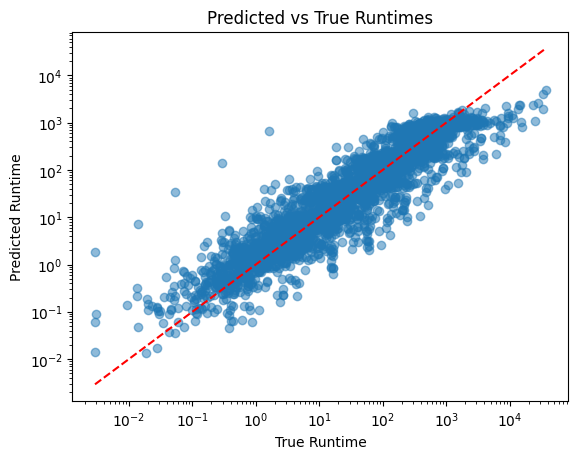

In [11]:
# Plot predicted vs actual runtimes
import matplotlib.pyplot as plt
all_preds = []
all_trues = []
model.eval()
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        x = data.type
        edge_index = data.edge_index
        pe = torch.cat((data.laplacian_eigenvector_pe, data.random_walk_pe, data.degree_pe), dim=-1)
        node_type = data.node_type
        pred = torch.exp(model(x, pe, node_type, edge_index, data.batch))
        all_preds.append(pred.reshape(-1).cpu())
        all_trues.append(data.y.cpu())
all_preds = torch.cat(all_preds)
all_trues = torch.cat(all_trues)
plt.scatter(all_trues, all_preds, alpha=0.5)
plt.plot([all_trues.min(), all_trues.max()], [all_trues.min(), all_trues.max()], 'r--')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("True Runtime")
plt.ylabel("Predicted Runtime")
plt.title("Predicted vs True Runtimes")
plt.show()

In [17]:
idx = 0  # Index of the sample to inspect
model.eval()
with torch.no_grad():
    sample_data = test_dataset[idx]
    sample_data = sample_data.to(device)
    x = sample_data.type
    edge_index = sample_data.edge_index
    pe = torch.cat((sample_data.laplacian_eigenvector_pe, sample_data.random_walk_pe, sample_data.degree_pe), dim=-1)
    node_type = sample_data.node_type
    pred_runtime = torch.exp(model(x, pe, node_type, edge_index))
    print(f"Predicted runtime: {pred_runtime}, True runtime: {sample_data.y}")

Predicted runtime: tensor([[  1.5501,   6.1753,  29.2380, 120.5505, 587.0823]], device='cuda:0'), True runtime: tensor([8.5089e-01, 5.0151e+00, 3.3440e+01, 2.2418e+02, 1.0588e+03],
       device='cuda:0')
